# Confirmation Bias Project
## Behavioural analyses
Launching analysis for each of the experiments: ['3reps', 'CJ']


We recommend to run this script in Jupyter Notebook. It is possible to not visualize some plots in JupyterLab

__Metadprime is computed using the library from:__

pip install git+https://github.com/LegrandNico/metadPy.git

##### Import important functions and libraries

In [1]:
import os, glob, platform, sys
import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy
import scipy.stats as stats
from scipy import signal
import seaborn as sns
from statsmodels.formula.api import ols
import statsmodels.formula.api as smf
from statsmodels.stats.anova import AnovaRM
#import pingouin as pg

from statsmodels.stats.multicomp import (pairwise_tukeyhsd, MultiComparison)
from matplotlib.lines import Line2D
import statsmodels as sms
#import ptitprince as pt
pd.options.display.max_columns = None # display all the columns in pandas dataframe
#import plotly.graph_objects as go
#import plotly.express as px
#from plotly.subplots import make_subplots



In [2]:
import pymc
import hddm
pymc.__version__

/opt/conda/lib/python3.8/site-packages/IPython/parallel.py:12: ShimWarning: The `IPython.parallel` package has been deprecated since IPython 4.0. You should import from ipyparallel instead.
  warn("The `IPython.parallel` package has been deprecated since IPython 4.0. "


'2.3.8'

##### Important functions

In [3]:
def RT_filter(x, sd): 
    # this function was used to filter those trials with a RT that are above X standard deviation from the mean
    rt_mean = x['RT'].mean()
    up_lim = rt_mean + sd * x['RT'].std()
    x = x.loc[(x['RT'] < up_lim) & (x['RT'] > 0), : ]
    return x #the same dataframe with RT filtered

def log_reg_fit(x, f): # this function was used to calculate the log linear regression between two vectors
    reg = smf.glm(formula = f, data = x, family=sm.families.Binomial()).fit()
    params = reg.params
    PSE = - reg.params.Intercept/reg.params[1]
    # concatenating parameters
    out = pd.DataFrame({'intercept':[params[0]] , 'weight':[params[1]],'PSE': PSE})
    return out #intercept + weight

def z_RT(x):
    # this function was used to calculate the z score of the RT values from a dataframe 
    rt_mean = x['RT'].mean()
    rt_sd   = x['RT'].std()
    x['RTz'] = (x['RT']- rt_mean)/rt_sd
    x['1/RTz']= 1/x['RT']
    rt_mean1  = x['1/RTz'].mean()
    rt_sd1    = x['1/RTz'].std()
    x['1/RTz']=(x['1/RTz']- rt_mean1)/rt_sd1
    return x


def z_DV(x):
    # this function was used to calculate the z score of the DV values from a dataframe 
    dv_mean = x['DV'].mean()
    dv_sd   = x['DV'].std()
    x['DVz'] = (x['DV']- dv_mean)/dv_sd
    return x

def cartesian(arrays, out=None):
    """
    Examples
    --------
    >>> cartesian(([1, 2, 3], [4, 5], [6, 7]))
    """

    arrays = [np.asarray(x) for x in arrays]
    dtype = arrays[0].dtype

    n = np.prod([x.size for x in arrays])
    if out is None:
        out = np.zeros([n, len(arrays)], dtype=dtype)

    #m = n / arrays[0].size
    m = int(n / arrays[0].size) 
    out[:,0] = np.repeat(arrays[0], m)
    if arrays[1:]:
        cartesian(arrays[1:], out=out[0:m, 1:])
        for j in range(1, arrays[0].size):
        #for j in xrange(1, arrays[0].size):
            out[j*m:(j+1)*m, 1:] = out[0:m, 1:]
    return out

def sdt(x):
    dprime = x.dprime()
    c = x.criterion()
    out = pd.DataFrame([[dprime, c]], columns=['dprime', 'c'])   
    return out

Splitting confidence in previous trial in two levels for each subject to have a factor level in the model.

__With this DDM model is not possible to use continuous regressors (Confidence1)__

In [86]:
def split_confi(x):
    x['conf_lvl1'] =  'L'  
    s = np.median(x.Confidence1)
    x.loc[s < x.Confidence1, 'conf_lvl1'] = 'H' 
    
    x['metad_lvl1'] =  'L'  
    z = np.median(x.metad)
    x.loc[z < x.metad, 'metad_lvl1'] = 'H'
    #x.insert(5, 'conf_mean', s) 
    return x

def split_rtconfi(x):
    x['rtconf_lvl1'] =  'L'  
    s = np.median(x.rtconf1)
    x.loc[s < x.rtconf1, 'rtconf_lvl1'] = 'H' 
   
    return x




__Plotting functions__

In [4]:
colpal1 = ["orange","green"]
colpal1a = ["deeppink","deepskyblue"]
#colpal2 = ['black','green','blue']
colpal2 = ['darkorange','lime','royalblue']
colpal1b = ['dodgerblue','navy']
colpal3 = ['springgreen','darkviolet']
colpal2 = ['yellow','turquoise','navy']


In [5]:
# Importing behavioral data from experiment 
if platform.system() == 'Darwin':
    sys_dir = os.path.join('/Users','alex','Library','CloudStorage','OneDrive-UniversitatdeBarcelona') # macv
    results_path = '/Users/alex/OneDrive - Universitat de Barcelona/Projects/Condcision/'
 
if platform.system() == 'Linux':
    sys_dir = os.path.join('/home/jovyan/work', 'OneDrive Biz')  # Linux   
    results_path = '/home/jovyan/work/OneDrive Biz/PROJECTS/Condcision/' # Linux Mundet

# some folders with interesting custom functions
path_utils = os.path.join(sys_dir, 'TOOLBOXES','decoding_toolbox_py','Helper_funcs') 
psychofits = os.path.join(sys_dir, 'TOOLBOXES','psychofit-master')  
sys.path.append(path_utils)
sys.path.append(psychofits)

#import psychofit as psy

In [90]:
df = pd.read_csv('./all_data_CSV/cond_df.csv')

Concatenating datasets

df.to_csv('./all_data_CSV/cond_df.csv')

# Preparing the data in long format

In [83]:
# df to long format
dflong = pd.melt(df, id_vars=['exp_ID','id_subj','nrep','rep','nblock','ntrial','stimuli1','Stimuli', 'response2','response1','Responses', 'accuracy1', 'Confidence1','Confidence','rtconf1','ITI','trial_type','rt','metad'], value_vars=['d1', 'd2', 'd3', 'd4', 'd5', 'd6'])
dflong.shape
dflong.rename(columns={'variable' : "stim", 'value' : 'dv'}, inplace=True)

out = pd.melt(df, id_vars=['exp_ID','id_subj','nrep','rep','nblock','ntrial','stimuli1','Stimuli', 'response2','response1','Responses', 'accuracy1', 'Confidence1','ITI','trial_type','rtconf1','metad'], value_vars=['o1', 'o2', 'o3', 'o4', 'o5', 'o6'])
dflong['orient'] = out.value
dflong.orient = np.rad2deg(dflong.orient) # transform to degrees
del out

dflong = dflong.sort_values(['nblock','id_subj','ntrial','nrep',],ascending=[True,True,True,True]) # reorder variables
dflong.reset_index(drop=True, inplace=True)
dflong.insert(5, "stim_cond", "D")
dflong.loc[(dflong.dv < 0), "stim_cond"]  = "C"


dflong.insert(7, 'cong_deci', "I") # if stim is congruent with previous repetition decosion category
# an stimuli is expected when the previous dv and previous deci were the same (i.e.DV==D & pre_deci == D)
dflong.loc[(dflong['response1'] == 0) & (dflong.stim_cond == 'C') | (dflong['response1'] == 1) & (dflong.stim_cond == 'D'), "cong_deci"]  = "C"



dflong.insert(8, 'cong_stim', 'I') # if stim is congruent with previous repetition mean category
dflong.loc[(dflong['response1'] == 0) & (dflong.stim_cond == 'C') | (dflong['response1'] == 'D') & (dflong.stim_cond == 'D'), 'cong_stim'] = 'C'

# relabeling variables
#dflong["cond-1"].replace({0: "C", 1: "D"}, inplace=True)
#dflong["deci"].replace({0: "C", 1: "D"}, inplace=True)
#dflong["deci-1"].replace({0: "C", 1: "D"}, inplace=True)
#dflong["deci-2"].replace({0: "C", 1: "D"}, inplace=True)


dflong['ov'] = signal.sawtooth(2*np.deg2rad(dflong.orient), 0.5) # orientation variable (here I define an ov to make stimuli that differ by less of 45 degrees or more than 135 as similar)
# plt.scatter(dflong.orient,dflong['ov']) # see here


dflong.head(5)

/opt/conda/lib/python3.8/site-packages/pandas/core/ops/array_ops.py:253: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  res_values = method(rvalues)


,exp_ID,id_subj,nrep,rep,nblock,stim_cond,ntrial,cong_deci,cong_stim,stimuli1,Stimuli,response2,response1,Responses,accuracy1,Confidence1,Confidence,rtconf1,ITI,trial_type,rt,metad,stim,dv,orient,ov
0,3diffs,1,0,diff,0,C,0,C,C,0,1,0,0,1,0,NaN,NaN,0.0,NaN,nonrepeat,1.646,NaN,d1,-0.022671,68.010090,0.511335
1,3diffs,1,0,diff,0,D,0,I,I,0,1,0,0,1,0,NaN,NaN,0.0,NaN,nonrepeat,1.646,NaN,d2,0.566085,35.236904,-0.216958
2,3diffs,1,0,diff,0,C,0,C,C,0,1,0,0,1,0,NaN,NaN,0.0,NaN,nonrepeat,1.646,NaN,d3,-0.622602,98.491445,0.811301
3,3diffs,1,0,diff,0,D,0,I,I,0,1,0,0,1,0,NaN,NaN,0.0,NaN,nonrepeat,1.646,NaN,d4,0.398017,31.455383,-0.300991
4,3diffs,1,0,diff,0,D,0,I,I,0,1,0,0,1,0,NaN,NaN,0.0,NaN,nonrepeat,1.646,NaN,d5,0.095505,114.648855,0.452248


Saving data to fit mixed GLM in R

__Accuracy, dprime and criterion calculation (for all the experiments)__

In [11]:
# function that I used to plot multiple data
def barsplot(data, dx, dy, hue, col, row, pal, size, yaxis, axislabels, sizepoint, dodge):    
    sns.set(font_scale = 1.5, style = 'ticks')         
    ort = "v"; pal = pal; sigma = .5
    g = sns.FacetGrid(data ,  row = row, col = col, height= size['height'], aspect=size['aspect'], margin_titles=True) # col="nrep",    
    if sizepoint == None:
        sizepoint = 6
    if yaxis != None:
        g.set(yaxis['ylim'], yaxis['yticks'])   

    g.map_dataframe(sns.stripplot, x = dx, y = dy, palette = pal, hue=hue, size = sizepoint, edgecolor = "white",
                    linewidth = 0.6, jitter = 0.2, orient = ort,alpha = 0.5, dodge=dodge)
    g.map_dataframe(sns.barplot, x = dx, y = dy, palette = pal, hue=hue,  linewidth = 0.6, orient = ort, dodge=dodge)
    
    #g.map_dataframe(sns.violinplot, x = dx, y = dy,  palette = pal,bw = .5, cut = 0.,scale = "area", width = .6, inner = None, orient = ort, linewidth = 0, zorder = 2)
    
    g.add_legend()

    sns.despine(offset = .5,  trim=True);
    # Set x-axis and y-axis labels
    g.set_axis_labels( axislabels['xlabel'] , axislabels['ylabel'], fontsize = 15 )
    #g.tight_layout()
    return g


## Drift diffusion analyses

 __HDDM cheat sheet__

 v     = drift rate
 a     = boundary separation
 t     = nondecision time
 z     = starting point
 dc    = drift driterion
 sv    = inter-trial variability in drift-rate
 st    = inter-trial variability in non-decision time
 sz    = inter-trial variability in starting-point


In [12]:
import hddm

# ============================================ #
# also compute BIC, AIC
# from https://groups.google.com/forum/#!searchin/hddm-users/bic%7Csort:date/hddm-users/Bo2vUcpR008/RLRpL0faptAJ
# ============================================ #
def aic(self):
    k = len(self.get_stochastics())
    logp = sum([x.logp for x in self.get_observeds()['node']])  
    return 2 * k - 2 * logp

def bic(self):
    k = len(self.get_stochastics())
    n = len(self.data)
    logp = sum([x.logp for x in self.get_observeds()['node']])
    return -2 * logp + k * np.log(n)

# model comparison function
def GLRT(mod1, mod2):
    
    chi_square = 2 * abs(mod1.logLike - mod2.logLike)
    delta_params = abs(len(mod1.coefs) - len(mod2.coefs)) 
    
    return {"chi_square" : chi_square, "df": delta_params, "p" : 1 - stats.chi2.cdf(chi_square, df=delta_params)}

__Model features__

In [93]:
mydata = df.copy()
mydata = mydata[mydata.rt >0.0]
mydata.rename(columns= {'Responses' : 'response', 'id_subj' : 'subj_idx'}, inplace=True)

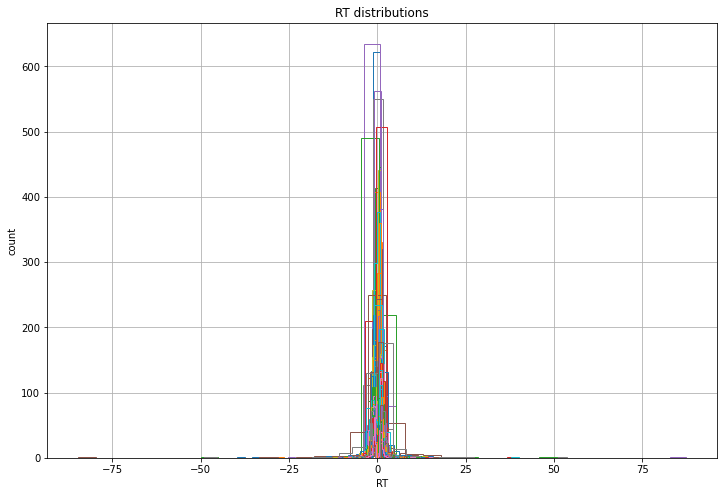

In [94]:
data = hddm.utils.flip_errors(mydata) #mydata.copy() #
#data = mydata.copy()
fig = plt.figure(figsize=[12,8])
ax = fig.add_subplot(111, xlabel='RT', ylabel='count', title='RT distributions')
for i, subj_data in data.groupby('subj_idx'):
    subj_data.rt.hist(bins=20, histtype='step', ax=ax)

In [15]:
def make_model(mypath, mydata, exp, model_name):
    if exp == 'all': # this is to analyze all the experiments together in the same models
        if model_name == 'stimcoding_nohist':
                    m = hddm.HDDMStimCoding(mydata, stim_col='Stimuli', split_param='v',
                        drift_criterion=False, bias=True, p_outlier=0.05,
                        include=('sv', 'sz'), group_only_nodes=['sv', 'sz'],
                        depends_on={ 'v':['nrep'],  't':['exp_ID']}) 
        elif model_name == 'stimcoding_dc_prevresp':
                    m = hddm.HDDMStimCoding(mydata, stim_col='Stimuli', split_param='v',
                            drift_criterion=True, bias=True, p_outlier=0.05,
                            include=('sv', 'sz'), group_only_nodes=['sv', 'sz'],
                            depends_on={ 'dc':['nrep','response1'], 'v':['nrep'], 't':['exp_ID']})
                
        elif model_name == 'stimcoding_z_prevresp':
                    m = hddm.HDDMStimCoding(mydata, stim_col='Stimuli', split_param='v',
                            drift_criterion=False, bias=True, p_outlier=0.05,
                            include=('sv', 'sz'), group_only_nodes=['sv', 'sz'],
                            depends_on={ 'v':['nrep'], 'z':['nrep','response1'], 't':['exp_ID']})
                
        elif model_name == 'stimcoding_zXdc_prevresp':
                    m = hddm.HDDMStimCoding(mydata, stim_col='Stimuli', split_param='v',
                            drift_criterion=True, bias=True, p_outlier=0.05,
                            include=('sv', 'sz'), group_only_nodes=['sv', 'sz'],
                            depends_on={ 'dc':['nrep','response1'], 'v':['nrep'], 'z':['nrep','response1'], 't':['exp_ID']})
                    
    if exp != 'all':
        if model_name == 'stimcoding_nohist':
                    m = hddm.HDDMStimCoding(mydata, stim_col='Stimuli', split_param='v',
                        drift_criterion=False, bias=True, p_outlier=0.05,
                        include=('sv', 'sz'), group_only_nodes=['sv', 'sz'],
                        depends_on={ 'v':['nrep']}) 
        elif model_name == 'stimcoding_dc_prevresp':
                    m = hddm.HDDMStimCoding(mydata, stim_col='Stimuli', split_param='v',
                            drift_criterion=True, bias=True, p_outlier=0.05,
                            include=('sv', 'sz'), group_only_nodes=['sv', 'sz'],
                            depends_on={ 'dc':['nrep','response1'], 'v':['nrep']})
                
        elif model_name == 'stimcoding_z_prevresp':
                    m = hddm.HDDMStimCoding(mydata, stim_col='Stimuli', split_param='v',
                            drift_criterion=False, bias=True, p_outlier=0.05,
                            include=('sv', 'sz'), group_only_nodes=['sv', 'sz'],
                            depends_on={ 'v':['nrep'], 'z':['nrep','response1']})
                
        elif model_name == 'stimcoding_zXdc_prevresp':
                    m = hddm.HDDMStimCoding(mydata, stim_col='Stimuli', split_param='v',
                            drift_criterion=True, bias=True, p_outlier=0.05,
                            include=('sv', 'sz'), group_only_nodes=['sv', 'sz'],
                            depends_on={ 'a':['nrep'],'dc':['nrep','response1'], 'v':['nrep'], 'z':['nrep','response1']})
                
        elif model_name == 'stimcoding_zXdc_prevresp_CJ_rep':
                    m = hddm.HDDMStimCoding(mydata, stim_col='Stimuli', split_param='v',
                            drift_criterion=True, bias=True, p_outlier=0.05,
                            include=('sv', 'sz'), group_only_nodes=['sv', 'sz'],
                            depends_on={ 'a':['nrep'],'dc':['nrep','response1','rep'], 'v':['nrep','rep'], 'z':['nrep','response1','rep']})
            
        elif model_name == 'stimcoding_zXdc_prevresp_CJ_confi':
                    m = hddm.HDDMStimCoding(mydata, stim_col='Stimuli', split_param='v',
                            drift_criterion=True, bias=True, p_outlier=0.05,
                            include=('sv', 'sz'), group_only_nodes=['sv', 'sz'],
                            depends_on={ 'a':['nrep'],'dc':['nrep','response1','confi'], 'v':['nrep','confi'], 'z':['nrep','response1','confi']})
                
        elif model_name == 'stimcoding_zXdc_prevresp_CJ_metad':
                    m = hddm.HDDMStimCoding(mydata, stim_col='Stimuli', split_param='v',
                            drift_criterion=True, bias=True, p_outlier=0.05,
                            include=('sv', 'sz'), group_only_nodes=['sv', 'sz'],
                            depends_on={ 'a':['nrep'],'dc':['nrep','response1','metad'], 'v':['nrep'], 'z':['nrep','response1','metad']})
          
# DEPRECATED:     if exp == '3reps_lag':
        if model_name == 'stimcoding_nohist':
                    m = hddm.HDDMStimCoding(mydata, stim_col='Stimuli', split_param='v',
                        drift_criterion=False, bias=True, p_outlier=0.05,
                        include=('sv', 'sz'), group_only_nodes=['sv', 'sz'],
                        depends_on={ 'v':['nrep', 'ITI']}) 
        elif model_name == 'stimcoding_dc_prevresp':
                    m = hddm.HDDMStimCoding(mydata, stim_col='Stimuli', split_param='v',
                            drift_criterion=True, bias=True, p_outlier=0.05,
                            include=('sv', 'sz'), group_only_nodes=['sv', 'sz'],
                            depends_on={ 'dc':['nrep','response1', 'ITI'], 'v':['nrep', 'ITI']})
                
        elif model_name == 'stimcoding_z_prevresp':
                    m = hddm.HDDMStimCoding(mydata, stim_col='Stimuli', split_param='v',
                            drift_criterion=False, bias=True, p_outlier=0.05,
                            include=('sv', 'sz'), group_only_nodes=['sv', 'sz'],
                            depends_on={ 'v':['nrep', 'ITI'], 'z':['nrep','response1', 'ITI']})
                
        elif model_name == 'stimcoding_zXdc_prevresp':
                    m = hddm.HDDMStimCoding(mydata, stim_col='Stimuli', split_param='v',
                            drift_criterion=True, bias=True, p_outlier=0.05,
                            include=('sv', 'sz'), group_only_nodes=['sv', 'sz'],
                            depends_on={ 'a':['nrep'],'dc':['nrep','response1', 'ITI'], 'v':['nrep', 'ITI'], 'z':['nrep','response1', 'ITI']})
                
            
    return m 

In [16]:
def run_model(m, model_filename, model_name, n_samples):
    import pickle
    #print("finding starting values")
    #try:
    #    m.find_starting_values() # this should help the sampling
    #except:
    #    print('finding starting samples has failed')

    #print("begin sampling")
    m.sample(n_samples, burn=n_samples/2, thin=3, db='pickle',
        dbname = model_filename + '.db')
    #m.save(model_filename) # save the model to disk
    
    return m
             

In [15]:
def savemodel_idx(m, model_filename):
    out_m = dict()
    out_m['dic'] = [m.dic]
    out_m['aic'] = [aic(m)]
    out_m['bic'] = [bic(m)]
    out_df = pd.DataFrame(out_m)
    out_df.to_csv(model_filename+'_params')

m = hddm.load(model_filename)

## 3 reps exp

In [101]:
exp_ID = '3reps' 
dat = mydata[mydata.exp_ID == exp_ID]
dat.reset_index(inplace = True, drop = True)
#dat['subj_idx'] = dat['subj_idx'].cat.remove_unused_categories()

In [16]:
exp_ID = '3reps' 
model_name = 'stimcoding_nohist'
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name+'_i'+exp_ID)
mstimcoding_nohist_3reps.save(model_filename+'_fm.db') #


NameError: name 'mstimcoding_nohist_3reps' is not defined

__No history model__

In [18]:
n_samples = 2000
model_name = 'stimcoding_nohist'
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name+'_i'+exp_ID)

In [19]:
mstimcoding_nohist_3reps = make_model(model_filename, dat, exp_ID, model_name)

In [20]:
mstimcoding_nohist_3reps = run_model(mstimcoding_nohist_3reps, model_filename, model_name, n_samples)
mstimcoding_nohist_3reps.save(model_filename+'_fm.db') # save the model to disk

 [-----------------100%-----------------] 2001 of 2000 complete in 2254.9 sec

ppc_data = hddm.utils.post_pred_gen(mstimcoding_nohist_3reps)


ppc_data.reset_index()

In [34]:
mstimcoding_nohist_3reps.print_stats()

                  mean         std       2.5q        25q        50q        75q     97.5q       mc err
a              1.50541   0.0629655    1.39506    1.46302    1.50179    1.54761   1.63504   0.00424201
a_std         0.329697   0.0499916   0.247758   0.292324   0.323369   0.359265  0.436787   0.00314503
a_subj.26       1.6377   0.0470459    1.55465    1.60396    1.63717    1.67013   1.73282   0.00304484
a_subj.27      1.18074   0.0265739    1.12733    1.16269    1.18117    1.19812   1.23936   0.00158564
a_subj.28       1.3264   0.0285476    1.27411    1.30617    1.32531    1.34807   1.38143    0.0017887
a_subj.29      1.55996    0.039383    1.48375    1.53288    1.56162    1.58916     1.635    0.0022777
a_subj.30      1.28295   0.0269051    1.22822    1.26653    1.28225     1.3004   1.33769   0.00164205
a_subj.31      2.09578   0.0515799    1.99698    2.05986    2.09424    2.12859   2.19878   0.00309141
a_subj.32      1.67756   0.0392653     1.6071    1.65069    1.67412    1.70437   1

dbfile = model_filename + '.db'

__Z model__

In [22]:
n_samples = 2000
model_name = 'stimcoding_z_prevresp'
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name+'_'+exp_ID)

In [23]:
mstimcoding_z_prevresp_3reps = make_model(model_filename, dat, exp_ID, model_name)

In [26]:
mstimcoding_z_prevresp_3reps = run_model(mstimcoding_z_prevresp_3reps, model_filename, model_name, n_samples)
mstimcoding_z_prevresp_3reps.save(model_filename+'_fm.db')

 [-----------------100%-----------------] 2001 of 2000 complete in 3401.8 sec

In [32]:
mstimcoding_z_prevresp_3reps.print_stats()

                     mean         std         2.5q        25q        50q        75q     97.5q       mc err
a                  1.5048   0.0627624      1.38686     1.4647    1.50356    1.54572   1.62503   0.00331738
a_std            0.313892   0.0478161     0.238962   0.277309   0.311675   0.341861  0.418919   0.00272486
a_subj.26         1.58608   0.0325785      1.51711    1.56508    1.58839    1.61042   1.64448   0.00178925
a_subj.27         1.21572     0.02652      1.16094     1.1963    1.21656    1.23449   1.26655   0.00153787
a_subj.28         1.31662   0.0261994      1.25991    1.29974    1.31565    1.33448   1.36613   0.00149524
a_subj.29         1.53976   0.0313396      1.47946    1.51828    1.53923    1.56122    1.5953   0.00181332
a_subj.30         1.32136   0.0299587      1.26446    1.29984    1.32118    1.34293   1.37874   0.00151357
a_subj.31           2.064   0.0429863      1.97606    2.03489    2.06195    2.09137   2.15145   0.00243281
a_subj.32         1.67041   0.0416435

__DC model__

In [28]:
n_samples = 2000
model_name = 'stimcoding_dc_prevresp'
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name+'_'+exp_ID)

In [29]:
mstimcoding_dc_prevresp_3reps = make_model(model_filename, dat, exp_ID, model_name)

In [30]:
mstimcoding_dc_prevresp_3reps = run_model(mstimcoding_dc_prevresp_3reps, model_filename, model_name, n_samples)
mstimcoding_dc_prevresp_3reps.save(model_filename+'_fm.db')

 [-----------------100%-----------------] 2001 of 2000 complete in 4362.1 sec

In [35]:
mstimcoding_dc_prevresp_3reps.print_stats()

                      mean         std       2.5q        25q        50q        75q      97.5q       mc err
a                   1.6453    0.069838    1.51933    1.59478    1.64259    1.68852    1.78289   0.00447891
a_std             0.363748   0.0554649   0.273922   0.324249   0.353027    0.39982   0.482014    0.0036009
a_subj.26           1.7565   0.0477089       1.66    1.72036    1.76176    1.79111    1.85068   0.00341365
a_subj.27           1.3321   0.0356362    1.26468    1.30745    1.32975    1.35464    1.41097    0.0022389
a_subj.28           1.4155   0.0326206     1.3536    1.39379    1.41511    1.43789    1.47873   0.00191724
a_subj.29           1.6412   0.0409973    1.56666    1.60984    1.63706    1.66846    1.72955   0.00272804
a_subj.30          1.40392   0.0317311    1.34466    1.38303    1.40469    1.42588    1.46891    0.0018509
a_subj.31          2.32781   0.0682621    2.20502    2.27553    2.32285    2.37641    2.46132   0.00442297
a_subj.32          1.77586   0.044665

In [ ]:
mstimcoding_dc_prevresp_3reps = hddm.load(model_filename+'_fm.db')

In [36]:
coef = mstimcoding_dc_prevresp_3reps.gen_stats()

In [37]:
coef.print_stats()

AttributeError: 'DataFrame' object has no attribute 'print_stats'

In [90]:
coef.loc[['z(0)','dc(0.0)','dc(0.1)'], ['mean','2.5q','97.5q']]

,mean,2.5q,97.5q
z(0),0.470918,0.460131,0.482838
dc(0.0),0.428044,0.259995,0.606635
dc(0.1),0.568024,0.405174,0.72564


__DC x Z model__

In [90]:
n_samples = 2000
model_name = 'stimcoding_zXdc_prevresp'
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name+'_'+exp_ID)

In [91]:
mzXdc_prevr_3reps = make_model(model_filename, dat, exp_ID, model_name)

In [92]:
mzXdc_prevr_3reps = run_model(mzXdc_prevr_3reps, model_filename, model_name, n_samples)
mzXdc_prevr_3reps.save(model_filename+'_fm.db')

 [-----------------100%-----------------] 2001 of 2000 complete in 6003.4 sec

In [55]:
mzXdc_prevr_3reps.save(model_filename+'.db')

In [93]:
mzXdc_prevr_3reps.print_stats()

                         mean          std         2.5q          25q          50q          75q        97.5q       mc err
a(0)                  2.15387    0.0605193      2.04253      2.11413      2.15319      2.18964      2.27365   0.00364918
a(1)                  2.12845    0.0589371      2.01866      2.08942      2.12653      2.16463      2.24579   0.00336855
a(2)                  1.99787    0.0570963      1.88687      1.95968      1.99795      2.03449      2.11706    0.0032199
a_std                0.345591    0.0266134      0.29904      0.32607     0.342906     0.362819       0.4046   0.00136918
a_subj(0).68          1.63991    0.0644742      1.51289      1.59492      1.64242      1.68357      1.77235   0.00391864
a_subj(0).69          2.50071     0.112328       2.2697      2.42727      2.49897      2.57242      2.71531   0.00692725
a_subj(0).70           2.1023    0.0924722      1.93315      2.03958      2.09859      2.15942      2.31776   0.00548638
a_subj(0).71          3.22704   

__Effects confi__

In [ ]:
def split_rtconfi(x):
    x['rtconf_lvl1'] =  'L'  
    s = np.median(x.rtconf1)
    x.loc[s < x.rtconf1, 'rtconf_lvl1'] = 'H' 
   
    return x

In [103]:
dat = dat.groupby(['subj', 'nrep','nblock']).apply(split_rtconfi) # probably confidence changes as the experiment progresses
dat.reset_index(inplace = True)
dat = dat.dropna(subset=['rtconf_lvl1'])

In [105]:
n_samples = 2000
model_name = 'stimcoding_DC_prevresp_3reps_rtconfi'
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name+'_'+exp_ID)

In [109]:
mdc_prevr_3reps_DCrtconfi = hddm.HDDMStimCoding(dat, stim_col='Stimuli', split_param='v',
                            drift_criterion=True, bias=True, p_outlier=0.05,
                            include=('sv', 'sz'), group_only_nodes=['sv', 'sz'],
                            depends_on={ 'a':['nrep'], 'v':['nrep'], 'dc':['nrep','response1','rtconf_lvl1']})

In [110]:
mdc_prevr_3reps_DCrtconfi = run_model(mdc_prevr_3reps_DCrtconfi , model_filename, model_name, n_samples)
mdc_prevr_3reps_DCrtconfi.save(model_filename+'_fm.db')

 [-----------------100%-----------------] 2001 of 2000 complete in 6853.9 sec

In [111]:
mdc_prevr_3reps_DCrtconfi.print_stats()

                        mean         std        2.5q        25q          50q         75q       97.5q       mc err
a(0)                 1.65106   0.0669324     1.51083    1.60649      1.65146      1.6915     1.78537   0.00415173
a(1)                 1.65081   0.0686231     1.52402    1.60548      1.64572     1.68917     1.80374   0.00429467
a(2)                 1.63638   0.0700363      1.5002    1.58673      1.63656     1.68678     1.76494   0.00389311
a_std               0.358799   0.0331576    0.300846   0.335714     0.356609    0.378246    0.432263   0.00187479
a_subj(0).26         1.74973    0.070719     1.61467    1.70017      1.74283     1.79977      1.8817   0.00477293
a_subj(0).27          1.3123   0.0432138     1.23408    1.28396      1.30979     1.33961     1.40282   0.00266932
a_subj(0).28         1.43782   0.0439165     1.35534    1.40888      1.43479     1.46752     1.52664     0.002535
a_subj(0).29         1.68116   0.0507695     1.58757    1.64926      1.68058     1.71572

In [116]:
aic(mdc_prevr_3reps_DCrtconfi)

24779.781698715975

In [118]:
aic(mdc_prevr_3reps_Zrtconfi)

30059.63306344498

In [112]:
n_samples = 2000
model_name = 'stimcoding_Z_prevresp_3reps_rtconfi'
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name+'_'+exp_ID)

In [113]:
mdc_prevr_3reps_Zrtconfi = hddm.HDDMStimCoding(dat, stim_col='Stimuli', split_param='v',
                            drift_criterion=False, bias=True, p_outlier=0.05,
                            include=('sv', 'sz'), group_only_nodes=['sv', 'sz'],
                            depends_on={ 'a':['nrep'], 'v':['nrep'], 'z':['nrep','response1','rtconf_lvl1']})

In [114]:
mdc_prevr_3reps_Zrtconfi = run_model(mdc_prevr_3reps_Zrtconfi , model_filename, model_name, n_samples)
mdc_prevr_3reps_Zrtconfi.save(model_filename+'_fm.db')

 [-----------------100%-----------------] 2001 of 2000 complete in 5368.2 sec

In [115]:
mdc_prevr_3reps_Zrtconfi.print_stats()

                       mean         std         2.5q        25q        50q        75q     97.5q       mc err
a(0)                 1.5122   0.0588097      1.38965    1.47697    1.51653    1.55141   1.61909   0.00347442
a(1)                1.51045   0.0592886      1.39335    1.46945    1.51164    1.54835   1.62923   0.00315149
a(2)                1.49113   0.0564239       1.3825    1.45391    1.48973    1.53256   1.59255   0.00330539
a_std              0.302787   0.0263922     0.256996   0.284908   0.302325   0.318553  0.362363   0.00143841
a_subj(0).26        1.55451   0.0467502      1.45625     1.5245    1.55926    1.58623   1.64154    0.0026343
a_subj(0).27        1.22094   0.0381132      1.14904     1.1942    1.22153    1.24812   1.29518   0.00207964
a_subj(0).28        1.35823   0.0385431      1.28769      1.333    1.35867    1.38345    1.4388    0.0021476
a_subj(0).29        1.56569   0.0499558      1.47659    1.53275    1.56167    1.60265   1.65772   0.00272853
a_subj(0).30       

## 2 CJ Experiment

In [26]:
exp_ID = 'CJ' 
dat = mydata[mydata.exp_ID == exp_ID]
dat.reset_index(inplace = True, drop = True)
dat['subj_idx'] = dat['subj_idx'].cat.remove_unused_categories()
dat['nrep'] = dat['nrep'].cat.remove_unused_categories()
dat['Confidence'] = (dat['Confidence'] - dat['Confidence'].mean()) / dat['Confidence'].std() # rescale confidence values
dat['Confidence1'] = (dat['Confidence1'] - dat['Confidence1'].mean()) / dat['Confidence1'].std() # rescale confidence values


<ipython-input-26-3b87a8db7ebc>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['subj_idx'] = dat['subj_idx'].cat.remove_unused_categories()
<ipython-input-26-3b87a8db7ebc>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['nrep'] = dat['nrep'].cat.remove_unused_categories()
<ipython-input-26-3b87a8db7ebc>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:

__No history model__

In [39]:
n_samples = 2000
model_name = 'stimcoding_nohist'

hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name+'_'+exp_ID)

In [40]:
mstimcoding_nohist_CJ = make_model(model_filename, dat, exp_ID, model_name)

In [41]:
mstimcoding_nohist_CJ = run_model(mstimcoding_nohist_CJ, model_filename, model_name, n_samples)
mstimcoding_nohist_CJ.save(model_filename+'_fm.db') # save the model to disk

 [-----------------100%-----------------] 2001 of 2000 complete in 2372.9 sec

ppc_data = hddm.utils.post_pred_gen(mstimcoding_nohist_3reps)


ppc_data.reset_index()

In [42]:
mstimcoding_nohist_CJ.print_stats()

                    mean         std         2.5q         25q        50q        75q      97.5q       mc err
a                1.79351   0.0297792      1.73653     1.77374    1.79353    1.81531    1.85236   0.00184308
a_std            0.19068   0.0240802      0.14837    0.172984   0.189794   0.206101   0.240993   0.00147077
a_subj.107       1.67698   0.0547777      1.56868     1.63712     1.6767    1.71502    1.77696   0.00351937
a_subj.108       1.75774   0.0490068       1.6636     1.72539    1.75618    1.79343    1.85233   0.00285028
a_subj.109       1.79834   0.0535925       1.6933     1.76092    1.79911    1.83147    1.91576   0.00311303
a_subj.110       1.91407   0.0585256      1.80127     1.87542    1.91252    1.95394    2.03096   0.00369069
a_subj.111       1.97958    0.064096      1.86724     1.93489    1.97655    2.01781    2.10372    0.0038298
a_subj.112        1.7301   0.0549025      1.62011     1.69429    1.73022    1.76692    1.84257   0.00335273
a_subj.113       1.68629   0

dbfile = model_filename + '.db'

__Z model__

In [43]:
n_samples = 2000
model_name = 'stimcoding_z_prevresp'
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name+'_'+exp_ID)

In [44]:
mstimcoding_z_prevresp_CJ = make_model(model_filename, dat, exp_ID, model_name)

In [45]:
mstimcoding_z_prevresp_CJ = run_model(mstimcoding_z_prevresp_CJ, model_filename, model_name, n_samples)
mstimcoding_z_prevresp_CJ.save(model_filename+'_fm.db')

 [-----------------100%-----------------] 2001 of 2000 complete in 3502.7 sec

In [46]:
mstimcoding_z_prevresp_CJ.print_stats()

                      mean         std        2.5q        25q        50q        75q      97.5q       mc err
a                  1.76947   0.0270806     1.72054    1.75217    1.76845      1.787    1.82581    0.0016729
a_std             0.175716   0.0213915     0.13709   0.161193   0.174086   0.189404   0.224666   0.00132368
a_subj.107         1.65351   0.0469929     1.55794    1.62255    1.65328    1.68683    1.74155   0.00287524
a_subj.108         1.73334   0.0480089     1.64044    1.70083    1.73107    1.76708    1.83196   0.00268295
a_subj.109         1.78624   0.0534304     1.69491    1.74769    1.78555    1.82333    1.89331   0.00313803
a_subj.110         1.87495   0.0538481     1.77529    1.83554    1.87477    1.90964     1.9823   0.00313538
a_subj.111          1.9388   0.0590525     1.82439    1.90121    1.93714    1.97979    2.04981   0.00341159
a_subj.112         1.70274   0.0460149     1.62563    1.66919    1.70115    1.73422    1.78813   0.00264441
a_subj.113         1.68318  

__DC model__

In [47]:
n_samples = 2000
model_name = 'stimcoding_dc_prevresp'
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name+'_'+exp_ID)

In [48]:
mstimcoding_dc_prevresp_CJ = make_model(model_filename, dat, exp_ID, model_name)

In [49]:
mstimcoding_dc_prevresp_CJ = run_model(mstimcoding_dc_prevresp_CJ, model_filename, model_name, n_samples)
mstimcoding_dc_prevresp_CJ.save(model_filename+'_fm.db')

 [-----------------100%-----------------] 2001 of 2000 complete in 4256.6 sec

In [71]:
mstimcoding_dc_prevresp_CJ.print_stats()

                       mean         std         2.5q         25q         50q        75q      97.5q       mc err
a                   1.85791    0.035738      1.79079     1.83407     1.85844    1.87848    1.92443   0.00243897
a_std              0.197332   0.0262402     0.155885     0.17953    0.195076   0.210985   0.253299   0.00157013
a_subj.107          1.68883   0.0542755      1.58366     1.65263     1.68922    1.72369    1.80096    0.0035408
a_subj.108           1.8033   0.0520124      1.70803     1.76439     1.80152    1.84034     1.9094   0.00306621
a_subj.109           1.9048   0.0605848      1.78781     1.86596     1.90263    1.94786    2.02014   0.00391793
a_subj.110           2.0191   0.0589813       1.8965     1.98248     2.02067    2.05956    2.13647   0.00326522
a_subj.111          2.12723   0.0723549      1.98973     2.07936     2.12325    2.17444    2.27663   0.00460353
a_subj.112          1.74524    0.056348      1.63906     1.71127     1.74108    1.77855    1.87512   0.0

__DC x Z model__

In [19]:
# CJ experiment

'CJ'

In [58]:
n_samples = 2000
model_name = 'stimcoding_zXdc_prevresp'
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name+'_'+exp_ID)

In [59]:
mzXdc_prevr_CJ = make_model(model_filename, dat, exp_ID, model_name)

In [60]:
mzXdc_prevr_CJ = run_model(mzXdc_prevr_CJ, model_filename, model_name, n_samples)
mzXdc_prevr_CJ.save(model_filename+'_fm.db')

 [-----------------100%-----------------] 2001 of 2000 complete in 4320.2 sec

In [ ]:
mzXdc_prevr_CJ.print_stats()

In [20]:
dat

,exp_ID,subj_idx,npar,subj,nblock,ntrial,nrep,rep,stimuli1,Stimuli,rDV,response3,response2,response1,RepResponses,DV,response,SideResp1,SideResp,RepSideResp,r_map,accuracy1,accuracy,rt,d1,d2,d3,d4,d5,d6,o1,o2,o3,o4,o5,o6,Confidence1,trial_type,Confidence,metad,metad_3%,metad_97%,ITI
0,CJ,107,1,s01,0,0,0,diff,0,1,0.089044,0,0,0,0,0.08,1,L,L,1,45,0,1,2.044453,0.828372,-0.956710,0.360338,-0.087842,0.939380,-0.549273,0.718,0.017,2.105,1.929,2.380,0.177,NaN,nonrepeat,0.10,0.105,-0.254,0.477,NaN
1,CJ,107,1,s01,0,0,1,diff,1,1,0.068067,0,0,1,1,0.08,1,L,R,0,0,1,1,2.114065,-0.186164,-0.022671,0.287481,0.530953,0.415324,-0.616519,2.822,1.187,2.636,2.172,1.015,2.991,0.10,nonrepeat,0.35,0.105,-0.254,0.477,NaN
2,CJ,107,1,s01,0,1,0,diff,1,0,-0.027166,0,1,1,1,-0.01,1,R,L,0,45,1,0,1.752747,0.840586,-0.430107,0.129599,0.858411,-0.717341,-0.844146,0.848,1.347,2.698,0.841,0.111,1.632,0.35,nonrepeat,0.75,0.105,-0.254,0.477,NaN
3,CJ,107,1,s01,0,1,1,diff,0,0,0.001867,1,1,1,0,-0.01,0,L,R,0,45,0,1,1.981836,-0.668958,0.911887,0.596642,0.846197,-0.812598,-0.861971,0.130,0.820,0.627,0.725,3.068,1.625,0.75,nonrepeat,-0.15,0.105,-0.254,0.477,NaN
4,CJ,107,1,s01,0,2,0,diff,0,0,-0.086152,1,1,0,1,-0.11,0,R,R,1,45,1,1,2.481966,-0.637881,0.462198,-0.473916,0.087865,-0.446895,0.491718,1.713,2.145,2.935,1.998,1.788,0.985,-0.15,nonrepeat,0.40,0.105,-0.254,0.477,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15131,CJ,149,44,s39,3,41,1,rep,1,1,0.204563,1,1,0,0,0.21,1,R,L,0,45,0,1,0.697239,-0.986749,0.333836,0.939898,0.833984,-0.173432,0.279842,1.576,1.047,0.809,2.291,2.817,2.639,0.70,repeat,0.75,0.527,0.250,0.809,NaN
15132,CJ,149,44,s39,3,42,0,diff,1,1,0.289281,1,0,1,1,0.31,1,L,R,0,0,1,1,0.947157,-0.441802,0.799842,0.996958,0.829881,0.158129,-0.607324,1.790,0.864,2.355,2.423,1.116,1.725,0.75,repeat,0.70,0.527,0.250,0.809,NaN
15133,CJ,149,44,s39,3,42,1,rep,1,1,0.289281,0,1,1,1,0.31,1,R,L,0,45,1,1,0.690167,-0.441802,0.799842,0.996958,0.829881,0.158129,-0.607324,1.790,0.864,2.355,2.423,1.116,1.725,0.70,repeat,0.50,0.527,0.250,0.809,NaN
15134,CJ,149,44,s39,3,43,0,diff,1,0,-0.296323,1,1,1,0,-0.31,0,L,L,1,0,1,1,0.989039,-0.073082,0.026231,-0.467267,-0.211629,-0.576766,-0.475425,0.364,0.403,1.780,2.832,1.737,0.206,0.50,repeat,0.60,0.527,0.250,0.809,NaN


In [51]:
n_samples = 2000
model_name = 'stimcoding_dc_prevresp_trial_type'
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name+'_'+exp_ID)

In [52]:
mdc_prevr_CJ_trial_type = hddm.HDDMStimCoding(dat, stim_col='Stimuli', split_param='v',
                            drift_criterion=True, bias=True, p_outlier=0.05,
                            include=('sv', 'sz'), group_only_nodes=['sv', 'sz'],
                            depends_on={ 'a':['nrep'],'dc':['nrep','response1', 'trial_type'], 'v':['nrep','trial_type']})

In [ ]:
mdc_prevr_CJ_trial_type = run_model(mdc_prevr_CJ_trial_type , model_filename, model_name, n_samples)
mdc_prevr_CJ_trial_type.save(model_filename+'_fm.db')

 [-----------------68%-----             ] 1361 of 2000 complete in 5284.0 sec

In [72]:
mdc_prevr_CJ_trial_type.print_stats()

                                 mean         std         2.5q         25q        50q         75q      97.5q       mc err
a(0)                          1.86205   0.0343455      1.79794     1.83898    1.86116     1.88257    1.93834   0.00226156
a(1)                          1.86808   0.0337641      1.80798     1.84411    1.86644     1.89355    1.92813   0.00209392
a_std                        0.194736    0.018515     0.161031    0.181534   0.194659    0.206273   0.231333   0.00115816
a_subj(0).107                 1.69218   0.0643094      1.57234     1.65076    1.69011     1.73255    1.82931   0.00352478
a_subj(0).108                 1.80443   0.0682379      1.67862     1.75633    1.80399       1.855    1.94175   0.00419004
a_subj(0).109                 1.98537   0.0727579      1.84305     1.93401    1.98857     2.03711    2.12535   0.00474394
a_subj(0).110                 2.02227   0.0802006      1.86824     1.97138     2.0194     2.07267    2.19236   0.00470993
a_subj(0).111           

In [ ]:
   'stimcoding_zXdc_prevresp_CJ_rep' 'stimcoding_zXdc_prevresp_CJ_confi' 'stimcoding_zXdc_prevresp_CJ_metad' 

__Confidence effect on DC and Z parameters__

__metad do not work for this analisys as there is one unique value for each participant__

In [37]:
dat = dat.groupby(['subj', 'nrep','nblock']).apply(split_confi) # probably confidence changes as the experiment progresses
dat.reset_index(inplace = True)
dat = dat.dropna(subset=['conf_lvl1'])

In [77]:
n_samples = 2000
model_name = 'stimcoding_zXdc_prevresp_CJ_confi'
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name+'_'+exp_ID)

In [78]:
mdc_prevr_CJ_confi = hddm.HDDMStimCoding(dat, stim_col='Stimuli', split_param='v',
                            drift_criterion=True, bias=True, p_outlier=0.05,
                            include=('sv', 'sz'), group_only_nodes=['sv', 'sz'],
                            depends_on={ 'a':['nrep'],'dc':['nrep','response1'], 'v':['nrep'], 'z':['nrep','response1','Confidence1']})

In [79]:
mdc_prevr_CJ_confi = run_model(mdc_prevr_CJ_confi , model_filename, model_name, n_samples)
mdc_prevr_CJ_confi.save(model_filename+'_fm.db')

 [-----------------100%-----------------] 2001 of 2000 complete in 6285.9 sec

In [80]:
mdc_prevr_CJ_confi.print_stats()

                           mean          std         2.5q          25q          50q          75q        97.5q       mc err
a(0)                    2.14927    0.0609232      2.02555      2.10829      2.15341      2.19005      2.25874   0.00384658
a(1)                    2.12365    0.0573695      2.01452      2.08278      2.12469      2.15909      2.24258   0.00357304
a(2)                    1.99915    0.0560342      1.88684       1.9654      1.99615      2.03509      2.10799   0.00287142
a_std                   0.34888    0.0296941     0.297464     0.326795     0.347676     0.364984     0.419195   0.00165243
a_subj(0).68            1.63867    0.0655122      1.51629      1.59154      1.63328      1.68554        1.777   0.00384378
a_subj(0).69            2.49692      0.11567      2.27873      2.42054      2.49345      2.57594      2.72726   0.00674295
a_subj(0).70            2.11722    0.0883371      1.95274      2.05945      2.11695      2.17219      2.29483   0.00510575
a_subj(0).71    

__Effects confi__

In [66]:
n_samples = 2000
model_name = 'stimcoding_Z_prevresp_CJ_confi'
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name+'_'+exp_ID)

In [67]:
mdc_prevr_CJ_Zconfi = hddm.HDDMStimCoding(dat, stim_col='Stimuli', split_param='v',
                            drift_criterion=False, bias=True, p_outlier=0.05,
                            include=('sv', 'sz'), group_only_nodes=['sv', 'sz'],
                            depends_on={ 'a':['nrep'], 'v':['nrep'], 'z':['nrep','response1','conf_lvl1']})

In [68]:
mdc_prevr_CJ_Zconfi = run_model(mdc_prevr_CJ_Zconfi , model_filename, model_name, n_samples)
mdc_prevr_CJ_Zconfi.save(model_filename+'_fm.db')

 [-----------------100%-----------------] 2001 of 2000 complete in 4630.4 sec

In [69]:
mdc_prevr_CJ_Zconfi.print_stats()

                        mean         std        2.5q        25q        50q        75q      97.5q       mc err
a(0)                  1.7786   0.0315212     1.71691    1.75723    1.77939    1.80152     1.8386    0.0018237
a(1)                 1.75735   0.0304325     1.69685    1.73586    1.75809    1.77633    1.82403   0.00191485
a_std               0.176658    0.018069    0.143393   0.163901   0.175313   0.189099   0.211668   0.00119159
a_subj(0).107        1.63119   0.0609408     1.52055    1.58498    1.62824    1.67288    1.75194   0.00387676
a_subj(0).108        1.74354   0.0626766     1.62487    1.70066    1.74329    1.78483      1.862   0.00355829
a_subj(0).109        1.89434   0.0656592     1.77722    1.85006    1.89443    1.93987    2.02835   0.00394376
a_subj(0).110        1.87721   0.0650155      1.7564    1.82826    1.87546     1.9272    2.01588   0.00392688
a_subj(0).111        1.87132   0.0799028     1.71428    1.81542    1.86815    1.92382    2.03669   0.00460357
a_subj(0).

In [75]:
bic(mdc_prevr_CJ_Zconfi)

33820.61541139569

In [76]:
bic(mdc_prevr_CJ_DCconfi)

32171.413977057862

In [81]:
bic(mdc_prevr_CJ_ZxDCconfi)

34606.2553585862

In [62]:
n_samples = 2000
model_name = 'stimcoding_dc_prevresp_CJ_confi'
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name+'_'+exp_ID)

In [63]:
mdc_prevr_CJ_DCconfi = hddm.HDDMStimCoding(dat, stim_col='Stimuli', split_param='v',
                            drift_criterion=True, bias=True, p_outlier=0.05,
                            include=('sv', 'sz'), group_only_nodes=['sv', 'sz'],
                            depends_on={ 'a':['nrep'],'dc':['nrep','response1','conf_lvl1'], 'v':['nrep']})

In [64]:
mdc_prevr_CJ_DCconfi = run_model(mdc_prevr_CJ_DCconfi , model_filename, model_name, n_samples)
mdc_prevr_CJ_DCconfi.save(model_filename+'_fm.db')

 [-----------------100%-----------------] 2001 of 2000 complete in 5847.9 sec

In [65]:
mdc_prevr_CJ_DCconfi.print_stats()

                         mean         std        2.5q          25q        50q         75q       97.5q       mc err
a(0)                  1.86483   0.0364951      1.7955      1.84005    1.86216     1.89061     1.93599    0.0025266
a(1)                  1.86242   0.0380241     1.78753      1.83761    1.86325     1.88977     1.93556   0.00266927
a_std                0.198836   0.0211274     0.16268     0.185286   0.196823    0.213055    0.242359   0.00141886
a_subj(0).107         1.69123   0.0649455     1.55721      1.64799      1.689      1.7351     1.81831   0.00415027
a_subj(0).108         1.80566   0.0658419     1.68715      1.76318    1.80436      1.8469     1.93808   0.00396986
a_subj(0).109         2.00054   0.0787707     1.85502      1.94863     1.9969     2.05628     2.15449   0.00450136
a_subj(0).110          2.0393   0.0786871     1.89851       1.9885    2.03395     2.09163     2.20479   0.00444129
a_subj(0).111         2.01339   0.0817462     1.86228      1.96112    2.01011   

In [77]:
n_samples = 2000
model_name = 'stimcoding_Zxdc_prevresp_CJ_confi'
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name+'_'+exp_ID)

In [78]:
mdc_prevr_CJ_ZxDCconfi = hddm.HDDMStimCoding(dat, stim_col='Stimuli', split_param='v',
                            drift_criterion=True, bias=True, p_outlier=0.05,
                            include=('sv', 'sz'), group_only_nodes=['sv', 'sz'],
                            depends_on={ 'a':['nrep'],'dc':['nrep','response1','conf_lvl1'], 'v':['nrep'], 'z':['nrep','response1','conf_lvl1']})

In [79]:
mdc_prevr_CJ_ZxDCconfi = run_model(mdc_prevr_CJ_ZxDCconfi , model_filename, model_name, n_samples)
mdc_prevr_CJ_ZxDCconfi.save(model_filename+'_fm.db')

 [-----------------100%-----------------] 2001 of 2000 complete in 5774.3 sec

In [80]:
mdc_prevr_CJ_ZxDCconfi.print_stats()

                          mean         std         2.5q        25q          50q         75q       97.5q       mc err
a(0)                   1.88903   0.0386187      1.82092    1.86092      1.88839     1.91561     1.96378   0.00250208
a(1)                   1.87004   0.0406862      1.79524    1.84113      1.86794     1.89736     1.95131   0.00256193
a_std                 0.203212    0.022468     0.163573   0.187044     0.201749    0.217105     0.25616   0.00154267
a_subj(0).107          1.70446   0.0632247      1.57959    1.66183      1.70428     1.74648     1.83565    0.0036835
a_subj(0).108          1.83317   0.0680442      1.71669    1.78452      1.82983     1.87845     1.97713   0.00363977
a_subj(0).109          2.02062   0.0781627      1.87657    1.96792      2.01526     2.07204     2.17395   0.00469246
a_subj(0).110           2.0649   0.0690745      1.93943    2.01638      2.06643     2.11202     2.19854   0.00413623
a_subj(0).111          2.03447   0.0775919       1.8797     1.97